In [101]:
# Import the pandas library as pd for data manipulation
import pandas as pd

# Import the numpy library as np for numerical operations
import numpy as np

# Import the seaborn library as sns for statistical data visualization
import seaborn as sns

# Import the matplotlib.pyplot module as plt for plotting graphs and visualizations
import matplotlib.pyplot as plt

#Set a consistent, readable style for all charts in this project
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

**DATA IMPORTING**

In [ ]:
#Load the DatasetSV and renaming certain columns
df = pd.read_csv('fifa2026_player_performance_clean.csv')
df = df.rename(columns = {
    'player_name' : 'player',
    'market_value_eur_m' : 'market value mil',
    'minutes_played' : 'minutes played',
    'match_id' : 'match id',
    'shots_on_target': 'shots on target',
    'pass_accuracy_pct' : 'pass accuracy perc',
    'distance_covered_km' : 'distance covered km',
    'match_rating' : 'match rating',
    'yellow_card' : 'yellow card',
    'red_card' : 'red card',
    'fouls_committed' : 'fouls committed',
    'injured_flag' : 'injured flag'
})
df.columns = df.columns.str.title() #changing column title for better readability
df.head()

,Player,Nationality,Club,Position,Age,Market Value Mil,Season,Competition,Match Id,Minutes Played,...,Assists,Shots On Target,Pass Accuracy Perc,Tackles,Distance Covered Km,Match Rating,Yellow Card,Red Card,Fouls Committed,Injured Flag
0,Achraf Hakimi,Morocco,Paris Saint-Germain,RB,21,11.01,2025/26,Champions League,111378,53,...,0,0,NaN,2,5.79,5.8,False,False,0,False
1,Achraf Hakimi,Morocco,Paris Saint-Germain,RB,21,10.69,2025/26,Champions League,111379,63,...,0,0,85.2,2,10.31,6.9,False,False,3,False
2,Achraf Hakimi,Morocco,Paris Saint-Germain,RB,21,10.61,2025/26,Champions League,111380,90,...,0,0,94.8,4,14.50,7.5,False,False,0,False
3,Achraf Hakimi,Morocco,Paris Saint-Germain,RB,21,11.26,2025/26,Champions League,111381,12,...,0,0,74.9,1,0.91,4.0,False,False,3,False
4,Achraf Hakimi,Morocco,Paris Saint-Germain,RB,21,10.50,2025/26,Champions League,111382,39,...,0,0,78.0,3,4.36,5.0,False,False,2,False


In [126]:
df[df.duplicated()] #finding duplicates

,Player,Nationality,Club,Position,Age,Market Value Mil,Season,Competition,Match Id,Minutes Played,...,Assists,Shots On Target,Pass Accuracy Perc,Tackles,Distance Covered Km,Match Rating,Yellow Card,Red Card,Fouls Committed,Injured Flag


In [127]:
#filling null values
market_value_mean = df['Market Value Mil'].mean()
df['Market Value Mil'] = df['Market Value Mil'].fillna(market_value_mean)

pass_accuracy_fill = df['Pass Accuracy Perc'].quantile(0.50)
df['Pass Accuracy Perc'] = df['Pass Accuracy Perc'].fillna(pass_accuracy_fill)

distance_fill = df['Distance Covered Km'].quantile(0.5)
df['Distance Covered Km'] = df['Distance Covered Km'].fillna(distance_fill)

#replacing unkown values with player nationality
nationality_map = (
    df[df['Nationality'] != 'Unknown']
    .groupby('Player')['Nationality']
    .first()
)
df.loc[df['Nationality'] == 'Unknown', 'Nationality'] = (
    df.loc[df['Nationality'] == 'Unknown', 'Player']
    .map(nationality_map)
)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13397 entries, 0 to 13396
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Player               13397 non-null  str    
 1   Nationality          13397 non-null  str    
 2   Club                 13397 non-null  str    
 3   Position             13397 non-null  str    
 4   Age                  13397 non-null  int64  
 5   Market Value Mil     13397 non-null  float64
 6   Season               13397 non-null  str    
 7   Competition          13397 non-null  str    
 8   Match Id             13397 non-null  int64  
 9   Minutes Played       13397 non-null  int64  
 10  Goals                13397 non-null  int64  
 11  Assists              13397 non-null  int64  
 12  Shots On Target      13397 non-null  int64  
 13  Pass Accuracy Perc   13397 non-null  float64
 14  Tackles              13397 non-null  int64  
 15  Distance Covered Km  13397 non-null  float64
 1

In [128]:
df.describe()

,Age,Market Value Mil,Match Id,Minutes Played,Goals,Assists,Shots On Target,Pass Accuracy Perc,Tackles,Distance Covered Km,Match Rating,Fouls Committed
count,13397.000000,13397.000000,13397.000000,13397.000000,13397.000000,13397.000000,13397.000000,13397.000000,13397.000000,13397.000000,13397.000000,13397.000000
mean,28.273569,22.698472,106698.000000,59.996716,0.164813,0.127566,0.292006,75.239957,0.980817,6.480479,6.121983,1.297529
std,6.435837,28.211757,3867.525113,27.647981,0.440731,0.369907,0.621698,13.891650,1.363312,3.614861,1.231560,1.144203
min,17.000000,0.570000,100000.000000,1.000000,0.000000,0.000000,0.000000,30.000000,0.000000,0.190000,3.000000,0.000000
25%,23.000000,5.970000,103349.000000,38.000000,0.000000,0.000000,0.000000,67.000000,0.000000,3.750000,5.200000,0.000000
50%,28.000000,12.880000,106698.000000,67.000000,0.000000,0.000000,0.000000,77.300000,0.000000,6.310000,6.200000,1.000000
75%,34.000000,27.510000,110047.000000,86.000000,0.000000,0.000000,0.000000,85.700000,1.000000,8.870000,7.000000,2.000000
max,39.000000,220.870000,113396.000000,90.000000,4.000000,3.000000,6.000000,99.800000,10.000000,14.500000,10.000000,9.000000


In [130]:
df.describe(include = 'object')

,Player,Nationality,Club,Position,Season,Competition
count,13397,13397,13397,13397,13397,13397
unique,229,40,47,11,1,5
top,Amine Adli,England,Arsenal,ST,2025/26,League
freq,70,1670,1008,2434,13397,7521


In [132]:
# The dataset is at MATCH level: every row is one player's performance in one
# match, not one row per player. This matters for every aggregation choice
# made later in the project.

print('Dataset shape (rows, columns):', df.shape)
print('Number of unique players:', df['Player'].nunique())
print('Number of unique clubs:', df['Club'].nunique())
print('Number of unique match records:', df['Match Id'].nunique())
print('Seasons covered:', df['Season'].unique().tolist())
print('Competitions covered:', df['Competition'].unique().tolist())

Dataset shape (rows, columns): (13397, 21)
Number of unique players: 229
Number of unique clubs: 47
Number of unique match records: 13397
Season(s) covered: ['2025/26']
Competitions covered: ['Champions League', 'Domestic Cup', 'FIFA World Cup 2026', 'League', 'World Cup Qualifiers']


In [138]:
# Count records for each position
position_counts = df['Position'].value_counts()

print(position_counts)

Position
ST     2434
CM     1945
CAM    1465
RW     1431
LW     1425
CB     1384
CDM     986
RB      814
GK      810
LB      469
CF      234
Name: count, dtype: int64


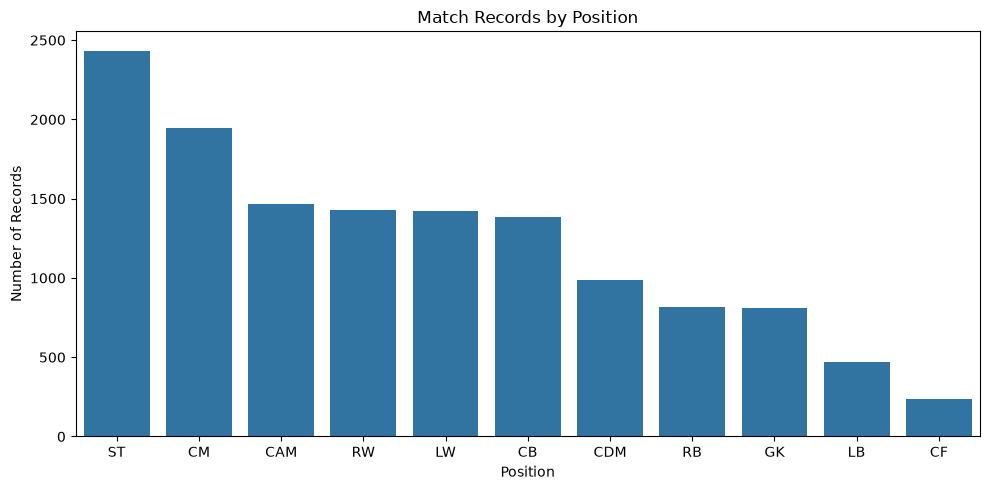

In [139]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=position_counts.index,
    y=position_counts.values
)

plt.title('Match Records by Position')
plt.xlabel('Position')
plt.ylabel('Number of Records')

plt.tight_layout()
plt.show()

In [140]:
# Find the top 10 nationalities by number of match records
top_nationalities = df['Nationality'].value_counts().head(10)

print(top_nationalities)

Nationality
England        1670
France         1299
Brazil         1127
Germany        1100
Netherlands    1006
Spain           977
Argentina       654
Italy           577
Portugal        572
Morocco         461
Name: count, dtype: int64


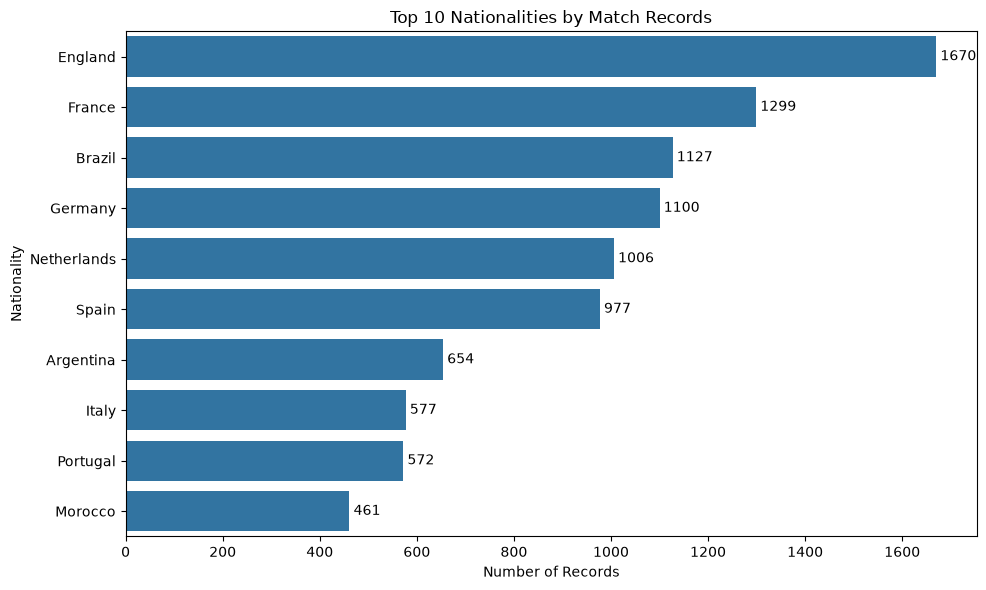

In [148]:
top_nationalities = df['Nationality'].value_counts().head(10)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=top_nationalities.values,
    y=top_nationalities.index
)

plt.title('Top 10 Nationalities by Match Records')
plt.xlabel('Number of Records')
plt.ylabel('Nationality')

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

In [150]:
player_stats = df.groupby('Player').agg(
    
Matches_Played=('Match Id', 'count'),
    
# Basic player information
Position=('Position', 'first'),
Nationality=('Nationality', 'first'),
Club=('Club', 'first'),
    
# Total performance statistics
Total_Goals=('Goals', 'sum'),
Total_Assists=('Assists', 'sum'),
Total_Shots_On_Target=('Shots On Target', 'sum'),
    
# Avg performance statistics
Avg_Pass_Accuracy=('Pass Accuracy Perc', 'mean'),
Avg_Distance_Covered=('Distance Covered Km', 'mean'),
Avg_Match_Rating=('Match Rating', 'mean'),
    
# Avg market value
Avg_Market_Value=('Market Value Mil', 'mean')
    
).reset_index()

player_stats.head()

,Player,Matches_Played,Position,Nationality,Club,Total_Goals,Total_Assists,Total_Shots_On_Target,Avg_Pass_Accuracy,Avg_Distance_Covered,Avg_Match_Rating,Avg_Market_Value
0,Achraf Hakimi,53,RB,Morocco,Paris Saint-Germain,2,3,1,76.647170,7.360189,6.218868,10.347736
1,Achraf Hakimi Jr,61,RB,Morocco,Paris Saint-Germain,1,3,2,76.960656,6.860820,6.088525,30.686860
2,Ademola Lookman,61,LW,Nigeria,Atalanta,14,19,23,76.214754,6.627869,6.268852,3.099950
3,Alejandro Balde,62,LB,Spain,Barcelona,0,7,2,77.011290,6.512258,6.074194,35.701266
4,Alejandro Garnacho,49,LW,Argentina,Chelsea,8,12,29,73.789796,6.898367,6.281633,66.024898


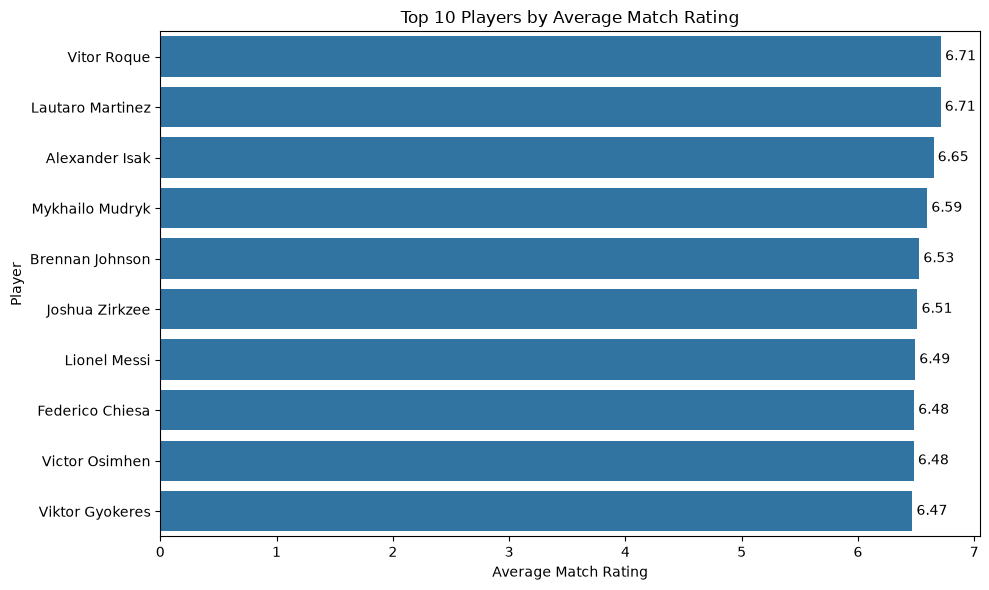

In [152]:
top_rating = (
    player_stats
    .sort_values('Avg_Match_Rating', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top_rating,
    x='Avg_Match_Rating',
    y='Player'
)

plt.title('Top 10 Players by Average Match Rating')
plt.xlabel('Average Match Rating')
plt.ylabel('Player')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

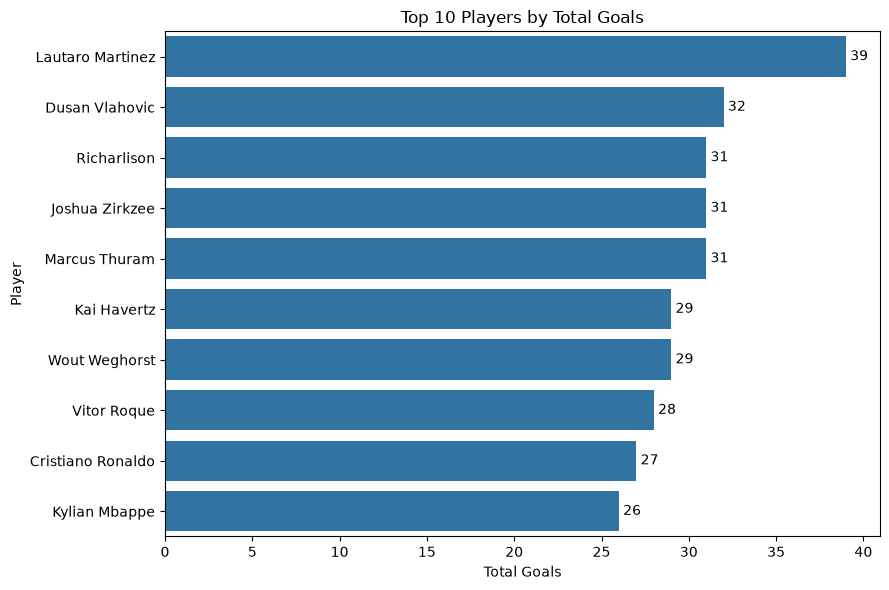

In [153]:
top_goals = (
    player_stats
    .sort_values('Total_Goals', ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=top_goals,
    x='Total_Goals',
    y='Player'
)

plt.title('Top 10 Players by Total Goals')
plt.xlabel('Total Goals')
plt.ylabel('Player')

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

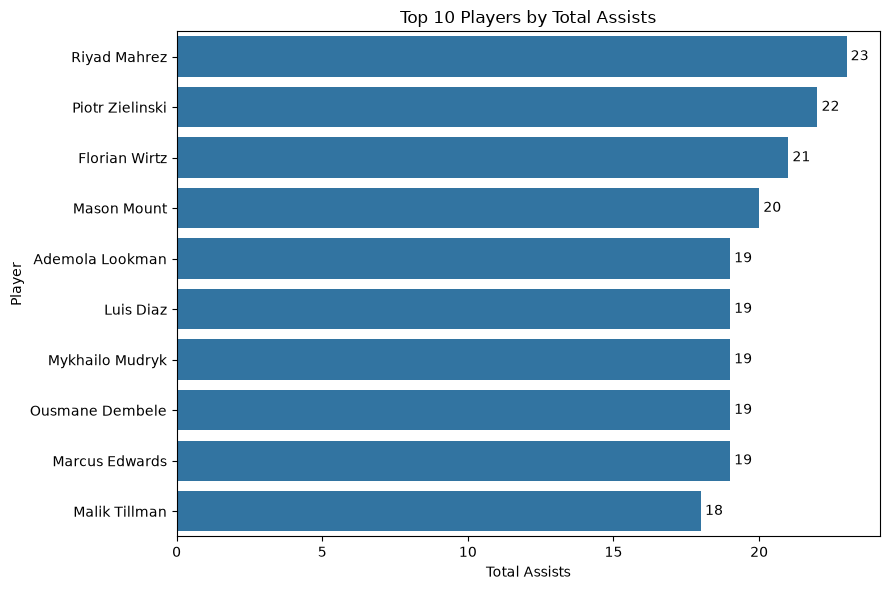

In [154]:
top_assists = (
    player_stats
    .sort_values('Total_Assists', ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=top_assists,
    x='Total_Assists',
    y='Player'
)

plt.title('Top 10 Players by Total Assists')
plt.xlabel('Total Assists')
plt.ylabel('Player')

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

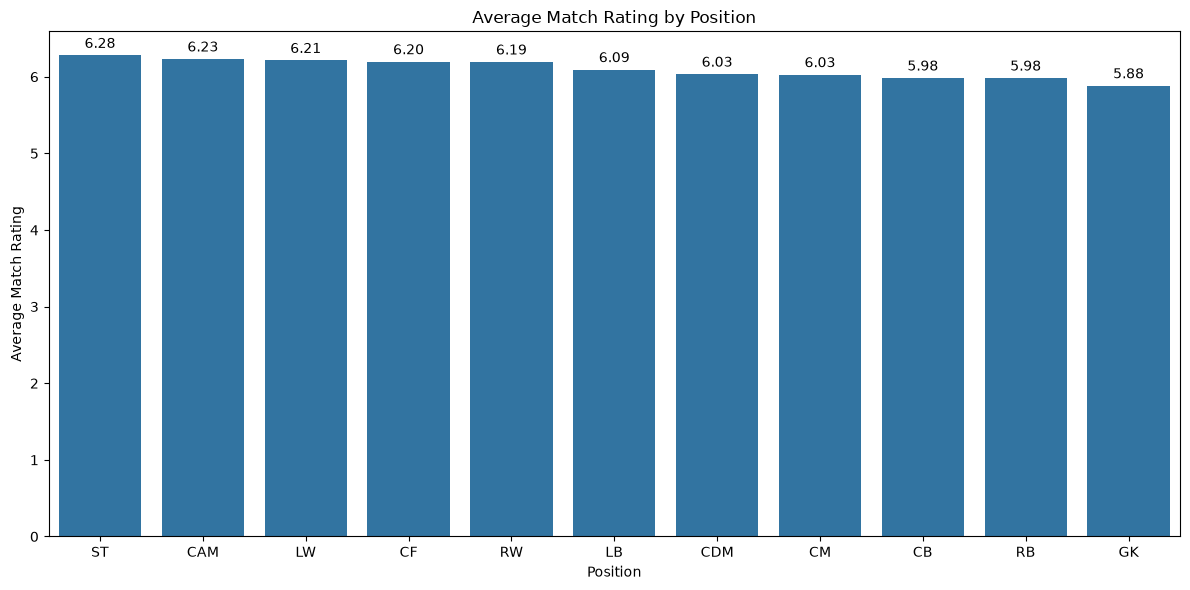

In [158]:
avg_rating_by_position = (
    df.groupby('Position')['Match Rating']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=avg_rating_by_position.index,
    y=avg_rating_by_position.values
)

plt.title('Average Match Rating by Position')
plt.xlabel('Position')
plt.ylabel('Average Match Rating')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

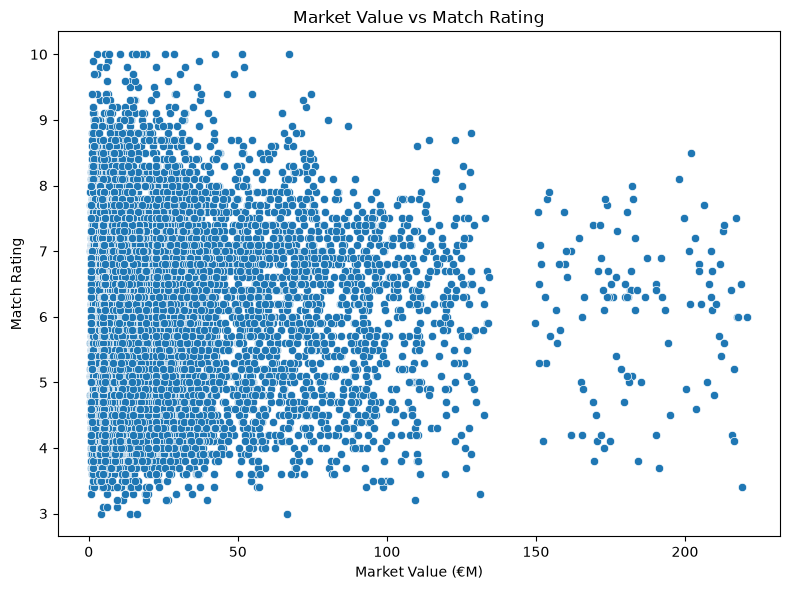

In [161]:
# Market value vs match rating

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='Market Value Mil',
    y='Match Rating'
)

plt.title('Market Value vs Match Rating')
plt.xlabel('Market Value (€M)')
plt.ylabel('Match Rating')

plt.tight_layout()
plt.show()

In [165]:
market_value_rating_corr = (
    df['Market Value Mil']
    .corr(df['Match Rating'])
)

print(
    "Correlation between Market Value and Match Rating:",
    round(market_value_rating_corr, 3)
)

Correlation between Market Value and Match Rating: -0.003
